In [1]:
from IPython.core.magic import register_cell_magic
@register_cell_magic
def skip(line, cell):
    return

import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from environment import MyEnv
from analysis_hydro import extract_data_cells
from fits_hydro import *
from phys_functions import *
from phys_constants import *
from IO import *
from cooling_distribution import *
from radiation_cooling import *
from obs_functions import *
from math import floor, log10

plt.ion()
%matplotlib ipympl

In [2]:
def sci_notation(num, decimal_digits=1, precision=None, exponent=None):
    """
    Returns a string representation of the scientific
    notation of the given number formatted for use with
    LaTeX or Mathtext, with specified number of significant
    decimal digits and precision (number of decimal digits
    to show). The exponent to be used can also be specified
    explicitly.
    """
    if num == 0.:
      return "$0$"
    if exponent is None:
        exponent = int(floor(log10(abs(num))))
    coeff = round(num / float(10**exponent), decimal_digits)
    if precision is None:
        precision = decimal_digits
    sci = r"${0:.{2}f}\cdot10^{{{1:d}}}$".format(coeff, exponent, precision)
    sci = sci.replace(f"1.{'0'*decimal_digits}\\cdot", "")
    return sci

In [3]:
key, k = 'sph_fid', 459
cell_data = open_celldata(key, k)
sh_data = open_rundata(key, 4)
if cell_data is False:
  extract_data_cells(key, [k], noOut=True)
  cell_data = open_celldata(key, k)
env = MyEnv(key)
cell_data = cell_data.loc[(cell_data.Sd == 1.).idxmax():].copy()

0.17074903687403892 -0.6488660109516843
Gamma^2 sh:  [ 1.15993401  0.2797101  10.73218047]
ShSt sh: [ 0.67203695 -1.37410308  1.42304748]


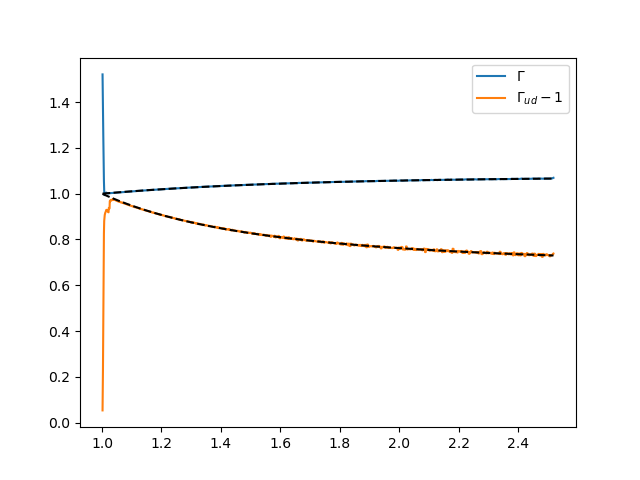

In [ ]:
lfac2_sh, ShSt_sh = get_hydrofits_shell(sh_data)
print("Gamma^2 sh: ", lfac2_sh)
print("ShSt sh:", ShSt_sh)
plt.figure()
x = sh_data.x.to_numpy() * c_ / env.R0
val = get_variable(sh_data, 'lfac', env)/env.lfac0
fit = np.sqrt(smooth_bpl0(x, *lfac2_sh))
plt.plot(x, val, label='$\\Gamma$')
plt.plot(x, fit, ls='--', c='k')
val = get_variable(sh_data, 'ShSt', env)/(env.lfac34-1)
fit = smooth_bpl0(x, *ShSt_sh)
plt.plot(x, val, label='$\\Gamma_{ud}-1$')
plt.plot(x, fit, ls='--', c='k')
plt.legend()

## Important
the scaling of a given cell after it has been shocked is not the same as the scaling behind the shock front! Also the initial values for $\Gamma^2$ and $\Gamma_{ud}-1$ need to be those from the fit behind the shock to reflect its propagation

In [ ]:
%%skip
lfac2_cell, ShSt_cell = get_hydrofits_shell(cell_data)
print("Gamma^2 sh: ", lfac2_cell)
print("ShSt sh:", ShSt_cell)
plt.figure()
x = cell_data.x.to_numpy() * c_ / env.R0
val = get_variable(cell_data, 'lfac', env)/env.lfac0
fit = np.sqrt(smooth_bpl0(x, *lfac2_cell))
plt.plot(x, val, label='$\\Gamma$')
plt.plot(x, fit, ls='--', c='k')
val = get_variable(cell_data, 'ShSt', env)/(env.lfac34-1)
fit = smooth_bpl0(x, *ShSt_cell)
plt.plot(x, val, label='$\\Gamma_{ud}-1$')
plt.plot(x, fit, ls='--', c='k')
plt.legend()

In [ ]:
var = 'ShSt'
rescale = False
plt.figure()
for data, label in zip([cell_data, sh_data], ['cell', 'sh']):
  x = data.x * c_/env.R0
  val = get_variable(data, var, env)
  if rescale:
    val *= x**2
  plt.plot(x, val, label=label)
plt.title(var)
plt.legend()

# to do
- créer une méthode pour bpl automatiques et remplacer withslopes
- gmin peut aller sous 1, adapter ajouter la correction de Ayache 22 (gmax peut aussi mais on bloque)

In [ ]:
T_label  = '$\\tilde{T}$'
nu_label = '$\\nu/\\nu_0$'
nF_label = '$\\nu F_\\nu/(\\nu_0F_0)_{\\rm VFC}$'
def slope_label(label):
  slabel = '$\\frac{\\rm d}{\\rm d\\log}' + label[1:]
  return slabel

# transform axs to put text (or anything)
def transx(ax):
  return transforms.blended_transform_factory(ax.transAxes, ax.transData)
def transy(ax):
  return transforms.blended_transform_factory(ax.transData, ax.transAxes)


In [ ]:
def syn_bpl(x, x_cm, x_M, p, norm=None):
  '''Synchrotron broken power law, controlled by log bar{gma}_c/gma_m
  x = nu'/nu'_m
  see Rahaman 2025 (cooling regimes)
  '''

  y = np.zeros(x.shape)
  a, c = 1./3., -p/2.
  if x_cm > 1:  # SC
    seg1 = (x <= 1.)
    seg2 = (x > 1.) & (x <= x_cm)
    seg3 = (x > x_cm)
    b = -(p-1)/2.
    y[seg1] = x[seg1]**a
    y[seg2] = x[seg2]**b
    y[seg3] = x_cm**b * (x[seg3]/x_cm)**c
  else:   # FC
    seg1 = (x <= x_cm)
    seg2 = (x > x_cm) & (x <= 1.)
    seg3 = (x > 1.)
    b = -0.5
    y[seg1] = (x[seg1]/x_cm)**a
    y[seg2] = (x[seg2]/x_cm)**b
    y[seg3] = x_cm**(-b) * x[seg3]**c
  y = x*y
  if norm is not None:
    i_norm = np.searchsorted(x, min(max(1., x_cm), x_M))
    y *= norm/y[i_norm]
  y[x>x_M] = 0.
  return y


In [ ]:
x = np.logspace(-3, 4 ,500)
p = 2.5
x_cm = 1e2
title= '$\\gamma_c/\\gamma_m=$' + sci_notation(x_cm)
fig, ax = plt.subplots()
ax.loglog(x, syn_bpl(x, x_cm, 1e5, p))
ax.set_xlabel("$\\nu'/\\nu'_m$")
ax.set_ylabel("$\\nu F_\\nu$ (arbitrary units)")
ax.set_title(title)
fig.tight_layout()


In [ ]:
def get_normalized_freqarr(dist, Nnu=500):
  cell0 = dist.iloc[0]
  log_nuM = 2*np.log10(cell0.gmax/cell0.gmin)
  nub = np.logspace(-8, log_nuM+1, Nnu)
  return nub

def get_coolgma(cell, dt, env):
  '''bar{gamma}_c from initial state cell during comov time dt'''
  tc1 = get_variable(cell, 'tc1', env)
  gma_c = tc1/dt
  return gma_c

def get_critlfacs(cell, dt, env):
  gmin  = cell.gmin
  gmax  = cell.gmax
  gmac = get_coolgma(cell, dt, env)
  return gmin, gmac, gmax

def get_critfreqs(cell, dt, env, norm=False):
  '''
  nu_m, nu_c, nu_M from state cell evolved over dt'
  '''
  gmin, gmac, gmax = get_critlfacs(cell, dt, env)
  nu_B = get_variable(cell, 'nu_B', env)
  num, nuc, nuM = nu_B*(np.array([gmin, gmac, gmax])**2) / (env.nu0 if norm else 1.)
  return num, nuc, nuM

In [ ]:
def get_coolstep_nF(k, j, dist, env, jstep=1, out_step=False):
  '''Get nuFnu of cooling step k of hydro step j'''
  cell0, cell, cell_next = dist.iloc[0], dist.iloc[j], dist.iloc[j+jstep]
  steps = split_hydrostep(cell, cell_next, env)
  step = steps.iloc[k]
  p = env.psyn
  K0 = norm_plaw_distrib(cell0.gmin, cell0.gmax, p)
  nub = get_normalized_freqarr(dist)
  nuobs = nub*env.nu0
  Tobs = env.Ts
  nF = nub * get_Fnu_step(nuobs, Tobs, step, K0, env, norm=True)
  if out_step:
    return step, nub, nF
  else:
    return nub, nF


def get_hydrostep_nF(j, dist, env, withsteps=True, jstep=1):
  '''Get nuFnu of hydro step j
    also outputs the corresponding dt' for analytical comparison'''
  cell0, cell, cell_next = dist.iloc[0], dist.iloc[j], dist.iloc[j+jstep]
  steps = split_hydrostep(cell, cell_next, env)
  dt = cell_next.tp - cell.tp
  p = env.psyn
  Nk = len(steps.index)
  nF_arr = []
  for k in range(Nk):
    nub, nF = get_coolstep_nF(k, j, dist, env, jstep)
    nF_arr.append(nF)
  nF_arr = np.array(nF_arr)
  if withsteps:
    return nub, nF_arr, dt
  else:
    return nub, nF_arr.sum(axis=0), dt

def get_cell_nF(dist, env, withsteps=True, r_gmax=1.5):
  '''Get nuFnu of cell history'''
  N = len(dist)
  Nj = len(dist.loc[dist['gmax']>1.])
  nF_arr = []
  t = 0.
  # j = 0
  # while (j + jstep < Nj):
  #   jstep = 1
  #   # jstep = min(jstep, Nj-j-1)
  #   try:
  #     while ((dist.iloc[j].gmax/dist.iloc[j+jstep].gmax < r_gmax)):
  #       jstep += 1
  #       if (j+jstep > Nj-1):
  #         print(f'ratio is {dist.iloc[j].gmax/dist.iloc[j+jstep].gmax} between steps \
  #             {j} and {j+jstep}')
  #         break
  #   except IndexError:
  #     print(dist.iloc[j].gmax/dist.iloc[j+jstep-1].gmax)
  #     print(Nj, j, j+jstep, N)
  #   try:
  #     nub, nF, dt = get_hydrostep_nF(j, dist, env, withsteps=False, jstep=jstep)
  #   except IndexError:
  #     print(j, jstep)
  #  j += jstep
  # for j in range(Nj-1):
  #   nub, nF, dt = get_hydrostep_nF(j, dist, env, withsteps=False)
  #   nF_arr.append(nF)
  #   t += dt
  j = 0
  while (j < Nj - 1):
    gmax0 = dist.iloc[j].gmax
    jstep = 1
    # Find the largest jstep that keeps us in bounds and maintains the gmax ratio
    while (j + jstep < Nj) and (dist.iloc[j+jstep].gmax > gmax0/r_gmax):
      # avoid oversampling by stopping near the end
      if (j + jstep >= Nj - 1):
        break
      jstep += 1
    
    # Ensure jstep doesn't go out of bounds
    jstep = min(jstep, Nj - j - 1)
    
    print(j, jstep)
    nub, nF, dt = get_hydrostep_nF(j, dist, env, withsteps=False, jstep=jstep)
    nF_arr.append(nF)
    t += dt
    j += jstep
    
  nF_arr = np.array(nF_arr)
  if withsteps:
    return nub, nF_arr, t
  else:
    return nub, nF_arr.sum(axis=0), t

In [ ]:
def ax_add_synbpl(ax, nub, norm, state, dt, env):
  num, nuc, nuM = get_critfreqs(state, dt, env, True)
  x_cm = nuc/num
  x_M = nuM/num
  x = nub/num
  y = syn_bpl(x, x_cm, x_M, env.psyn, norm)
  ax.loglog(x, y, ls='--', c='k')
  for val, s in zip([num, nuc, nuM], ['m', 'c', 'M']):
    nu = val
    name = f"$\\nu_{s}$"
    ax.axvline(nu, ls=':', c='k', lw=.9)
    ax.text(nu, -0.01, name, ha='center', va='top', transform=transy(ax))

  
def set_slopes_ticks(ax, env):
  p = env.psyn
  slopes = [4/3, (3-p)/2, 1-p/2, 1/2]
  snames = ['$\\frac{4}{3}$', '$\\frac{3-p}{2}$', '$1-\\frac{p}{2}$', '$\\frac{1}{2}$']
  for val in slopes:
    ax.axhline(val, c='k', ls=':')
  ax.tick_params(axis='both', which='both', length=0, labelright=False)
  for val, name in zip(slopes, snames):
    ax.text(1.01, val, name, ha='left', va='center', transform=transx(ax))

def add_logslope(x, y, ax, env):
  logx, logy = np.log(x),  np.log(y)
  s = np.gradient(logy, logx)
  ax2 = ax.twinx()
  ax2.semilogx(x, s, c='k', ls='-.')
  set_slopes_ticks(ax2, env)
  ax2.set_ylim((0.5-p/2, 2))


In [ ]:
def plot_coolstep(k, j, dist, env):
  step, nub, nF = get_coolstep_nF(k, j, dist, env, out_step=True)
  fig, ax = plt.subplots()
  ax.loglog(nub, nF)
  ax_add_synbpl(ax, nub, nF.max(), step, step.dtp, env)

def plot_hydrostep(j, dist, env, jstep=1):
  nub, nF_arr, dt = get_hydrostep_nF(j, dist, env, withsteps=True, jstep=jstep)
  nF_tot = nF_arr.sum(axis=0)
  fig, ax = plt.subplots()
  ax.loglog(nub, nF_tot, c='k', zorder=100)
  ylims = ax.get_ylim()
  ax.set_ylim(ylims)
  colors = plt.cm.jet(np.linspace(0,1,nF_arr.shape[0]))
  for k, nF in enumerate(nF_arr):
    ax.loglog(nub, nF, c=colors[k])
  ax_add_synbpl(ax, nub, nF_tot.max(), dist.iloc[j], dt, env)
  #add_logslope(nub, nF_tot, ax, env)

def plot_cell(dist, env):
  nub, nF_arr, dt = get_cell_nF(dist, env)
  nF_tot = nF_arr.sum(axis=0)
  fig, ax = plt.subplots()
  colors = plt.cm.jet(np.linspace(0,1,nF_arr.shape[0]))
  ax.loglog(nub, nF_tot, c='k', zorder=100)
  ylims = ax.get_ylim()
  ax.set_ylim(ylims)
  for k, nF in enumerate(nF_arr):
    ax.loglog(nub, nF, c=colors[k])
  #dt = dist.iloc[-1].tp - dist.iloc[0].tp
  ax_add_synbpl(ax, nub, nF_tot.max(), dist.iloc[0], dt, env)
  #add_logslope(nub, nF_tot, ax, env)


In [ ]:

dist, env = generate_cellDistrib(data)
dist_sc, env_sc = generate_cellDistrib(data, 0.8)

In [ ]:
%%skip
plot_coolstep(0, 0, dist, env)

In [ ]:
%%skip
plot_hydrostep(0, dist_, env_)

In [ ]:
dist_, env_ = generate_cellDistrib(data, 2)


In [ ]:
plot_cell(dist, env)

In [ ]:
nub, nF_arr, t = get_cell_nF(dist_, env_)
nF = nF_arr.sum(axis=0)
print(nF_arr.shape[0])
plt.figure()
plt.loglog(nub, nF)

In [ ]:
def e_distrib(state, gmax_next, env, norm=True):
  '''
  Energy in the distribution before and after radiating
  '''
  Ne = get_variable(state, 'Ne', env)
  dgma = state.gmax - gmax_next
  e = Ne*dgma*(me_*c_*c_)
  return e

In [ ]:
%%skip
E_rad, E_dist = [], []
nub = get_normalized_freqarr(dist)
nuobs = nub*env.nu0
Tobs = env.Ts
N = len(dist.loc[dist['gmax']>1.])
cell0 = dist.iloc[0]
K0 = norm_plaw_distrib(cell0.gmin, cell0.gmax, p)
for j in range(N):
  cell, cell_next = dist.iloc[j], dist.iloc[j+1]
  steps = split_hydrostep(cell, cell_next, env)
  for k in range(len(steps)):
    step = steps.iloc[k]
    F = get_Fnu_step(nuobs, Tobs, step, K0, env, norm=False)
    F /= env.zdl
    erad = np.trapezoid(F, nuobs)
    gmax_next = gamma_synCooled(step.dtt, step.gmax)
    edist = e_distrib(step, gmax_next, env)
    E_rad.append(erad)
    E_dist.append(edist)
E_rad = np.array(E_rad)/E_rad[0]
E_dist = np.array(E_dist)/E_dist[0]
plt.semilogy(E_rad, label='rad')
plt.semilogy(E_dist, label='dist')
plt.legend()

Emission

In [ ]:
def get_normalized_freqarr(dist, Nnu=500):
  cell0 = dist.iloc[0]
  log_nuM = 2*np.log10(cell0.gmax/cell0.gmin)
  nub = np.logspace(-8, log_nuM+1, Nnu)
  return nub

def get_coolgma(cell, dt, env):
  '''bar{gamma}_c from initial state cell during comov time dt'''
  tc1 = get_variable(cell, 'tc1', env)
  gma_c = tc1/dt
  return gma_c

def get_critfreqs(cell, dt, env):
  '''
  nu_m, nu_c, nu_M from state cell evolved over dt'
  '''
  gmin  = cell.gmin
  gmax  = cell.gmax
  gma_c = get_coolgma(cell, dt, env)
  nu_B = get_variable(cell, 'nu_B', env)
  num, nuc, nuM = (1+env.z)*nu_B*(np.array([gmin, gma_c, gmax])**2)
  return num, nuc, nuM

def get_hydrostep_Fnus(j, dist, env, width_tol=1.1):
  cell0, cell, cell_next = dist.iloc[0], dist.iloc[j], dist.iloc[j+1]
  steps = split_hydrostep(cell, cell_next, env)
  p = env.psyn
  K0 = norm_plaw_distrib(cell0.gmin, cell0.gmax, p)
  nub = get_normalized_freqarr(dist)
  nuobs = nub*env.nu0
  Tobs = env.Ts
  nF_arr = np.array([nub * get_Fnu_step(nuobs, Tobs, steps.iloc[k], K0, env, norm=True, width_tol=width_tol) for k in range(len(steps))])
  #nF_arr /= env.nu0F0
  return nub, nF_arr

def Fnu_hydrostep(j, dist, env):
  cell0, cell, cell_next = dist.iloc[0], dist.iloc[j], dist.iloc[j+1]
  p = env.psyn
  K0 = norm_plaw_distrib(cell0.gmin, cell0.gmax, p)
  nub = get_normalized_freqarr(dist)
  nuobs = nub*env.nu0
  Tobs = env.Ts
  F = get_Fnu_hydrostep(nuobs, Tobs, cell, cell_next, K0, env)
  nF = nub*F
  return nub, nF 

def set_slopes_ticks(ax, env):
  p = env.psyn
  #ax.set_ylabel(slope_label(nF_label))
  #ax.yaxis.labelpad = 0
  slopes = [4/3, (3-p)/2, 1-p/2, 1/2]
  snames = ['$\\frac{4}{3}$', '$\\frac{3-p}{2}$', '$1-\\frac{p}{2}$', '$\\frac{1}{2}$']
  for val in slopes:
    ax.axhline(val, c='k', ls=':')
  ax.tick_params(axis='both', which='both', length=0, labelright=False)
  for val, name in zip(slopes, snames):
    ax.text(1.01, val, name, ha='left', va='center', transform=transx(ax))
  

def plot_hydrostep_Fnus(j, dist, env, width_tol=1.1, ax_in=None, withslope=True, nosteps=False, **kwargs):
  nub, nF_arr = get_hydrostep_Fnus(j, dist, env, width_tol)
  cell = dist.iloc[j]
  nF_tot = nF_arr.sum(axis=0)
  if ax_in is None:
    fig, ax = plt.subplots()
  else:
    ax = ax_in
    fig = plt.gcf()
    withslope = False

  colors = plt.cm.jet(np.linspace(0,1,nF_arr.shape[0]))
  ax.loglog(nub, nF_tot, c='k', zorder=-10, **kwargs)
  # nF_tot2 = Fnu_hydrostep(j, dist, env)
  # ax.scatter(nub, nF_tot2, c='k', marker='x', **kwargs)
  if ax_in is None:
    ymax = nF_tot.max()*2
    ymin = nF_tot.max()*1e-3
    ax.set_ylim((ymin, ymax))
  ax.set_xlabel(nu_label)
  ax.set_ylabel(nF_label)
  if nosteps == False:
    for k, nF in enumerate(nF_arr):
      ax.loglog(nub, nF, c=colors[k], **kwargs)
  
  # add crit freqs
  cell = dist.iloc[j]
  dt = cell.dtp
  nu_m, nu_c, nu_M = get_critfreqs(cell, dt, env)
  reg = check_coolRegime_cell(dist, env)
  loc = np.log10(nu_c/nu_m)/2.  # 'reg' is log gma_c/gma_m
  for val, s in zip([nu_m, nu_c, nu_M], ['m', 'c', 'M']):
    nu = val/env.nu0
    name = f"$\\nu_{s}$"
    ax.axvline(nu, ls=':', c='k', lw=.9)
    ax.text(nu, -0.01, name, ha='center', va='top', transform=transy(ax))

  title = '1 cell $\\nu F_\\nu$, ' + f'step {j}, ' + \
      '$(\\bar{\\gamma}_c/\\gamma_m)_{\\rm cell} =$' + f'$10^{{{reg:.1f}}}$, ' + \
      "$(\\bar{\\gamma}_c/\\gamma_m)_{\\rm step} =$" + f'$10^{{{loc:.1f}}}$'
  ax.set_title(title)

  if withslope:
    #fig2, ax2 = plt.subplots()
    ax2 =ax.twinx()
    s = logslope_arr(nub, nF_tot)
    ax2.set_ylim(-2, 2)
    ax2.semilogx(nub, s, c='k', ls='--')
    set_slopes_ticks(ax2, env)
  fig.tight_layout()

def get_val_rescaled(name, scalefacs):
  vals = []
  for sc in scalefacs:
    newenv = MyEnv(key, sc)
    vals.append(getattr(env, name))
  return vals

def plot_val_rescaled(name, scalefacs):
  vals = get_val_rescaled(name, scalefacs)
  fig, ax = plt.subplots()
  ax.plot(scalefacs, vals)

def get_cell_nuFnu(dist, env, arr=False, width_tol=1.1):
  nub = get_normalized_freqarr(dist)
  nF_arr = np.zeros((len(dist), len(nub)))
  nuobs = nub*env.nu0
  Tobs = env.Ts
  nu_B0 = get_variable(dist.iloc[0], 'nu_B', env)
  #gmax_cut = max(1., np.sqrt(nuobs.min()/nu_B0))
  gmax_cut = 1
  gmax_arr = dist.gmax.to_numpy()
  N = gmax_arr.size
  # np.searchsorted works in ascending order
  jcut = N - np.searchsorted(gmax_arr[::-1], gmax_cut, side = "right")
  print(f'Calculating over {jcut} sim iterations')
  jcut = max(jcut, 1)
  jcut = min(jcut, N-1)
  for j in range(jcut):
    # nu, nF = Fnu_hydrostep(j, dist, env)
    if dist.iloc[j].gmax == 1.:
      break
    nu, nF_steps = get_hydrostep_Fnus(j, dist, env, width_tol)
    nF = nF_steps.sum(axis=0)
    nF_arr[j] += nF
  nF_arr = nF_arr[:jcut]
  #nFtot = get_Fnu_cell(nuobs, Tobs, dist, env)
  if arr:
    return nub, nF_arr
  else:
    nF_tot = nF_arr.sum(axis=0)
    return nub, nF_tot

def plot_cell_nuFnu(dist, env, width_tol=1.1,
    ax_in=None, withslope=False, withsteps=True,
     **kwargs):
  nub = get_normalized_freqarr(dist)
  if ax_in is None:
    fig, ax = plt.subplots()
  else:
    ax = ax_in
    fig = plt.gcf()
    withslope = False
  ax.set_title('$\\nu F_\\nu$ from a cell')
  ax.set_xlabel(nu_label)
  ax.set_ylabel(nF_label)
  nu, nF_ = get_cell_nuFnu(dist, env, arr=withsteps, width_tol=width_tol)
  if len(nF_.shape) > 1:
    nF = nF_.sum(axis=0)
  else:
    nF = nF_
  reg = check_coolRegime_cell(dist, env)
  bpl = syn_bpl(nub/(1+env.z), reg, env.psyn, nF.max())
  #imax = np.argmax(nF)
  #bpl *= nF[imax]/bpl[imax]
  #ax.loglog(nub, bpl, ls='--', c='k')
  ylims = ax.get_ylim()
  ax.set_ylim(ylims)
  if withsteps:
    N = len(nF_)
    colors = plt.cm.jet(np.linspace(0,1,N))
    for i, nF_st in enumerate(nF_):
      ax.loglog(nu, nF_st, c=colors[i])
  
  
  # add crit freqs
  cell = dist.iloc[0]
  gmax_arr = dist.gmax.to_numpy()
  jcut = min(len(gmax_arr[gmax_arr>1.]) + 1, len(dist))
  dt = dist.iloc[jcut].tp
  nu_m, nu_c, nu_M = get_critfreqs(cell, dt, env)
  loc = np.log10(nu_c/nu_m)/2.  # 'reg' is log gma_c/gma_m
  for val, s in zip([nu_m, nu_c, nu_M], ['m', 'c', 'M']):
    nu = val/env.nu0
    name = f"$\\nu_{s}$"
    ax.axvline(nu, ls=':', c='k', lw=.9)
    ax.text(nu, -0.01, name, ha='center', va='top', transform=transy(ax))
  ax.loglog(nub, nF, c='k', **kwargs)
  title = '1 cell $\\nu F_\\nu$ ' + f'all steps, ' + \
      '$(\\bar{\\gamma}_c/\\gamma_m)_{\\rm cell} =$' + f'$10^{{{reg:.1f}}}$'
  ax.set_title(title)
  # if ax_in is None:
    # ymax = nF.max()*2
    # ymin = nF.max()*1e-3
    # ax.set_ylim((ymin, ymax))
  if withslope:
    #fig2, ax2 = plt.subplots()
    ax2 =ax.twinx()
    s = logslope_arr(nub, nF)
    ax2.set_ylim(-2, 2)
    ax2.semilogx(nub, s, c='k', ls='--')
    set_slopes_ticks(ax2, env)
    ax2.set_navigate(False)
  fig.tight_layout()
  

In [ ]:
%%skip
nu1, nF_arr = get_hydrostep_Fnus(0, dist, env)
nF1 = nF_arr.sum(axis=0)
nu2, nF2 = Fnu_hydrostep(0, dist, env)
fig, ax = plt.subplots()
ax.loglog(nu1, nF1)
ax.loglog(nu2, nF2, ls='--')
# they're the same

In [ ]:
%%skip
fig, ax = plt.subplots()
plot_hydrostep_Fnus(0, dist, env, ax_in=ax, ls='-')
plot_hydrostep_Fnus(0, dist_sc, env_sc, ax_in=ax, ls='--')
init = check_coolRegime_cell(dist, env)
new = check_coolRegime_cell(dist_sc, env_sc)
dummy_lst = [plt.plot([], [], c='k', ls=l)[0] for l in ['-', '--']]
names = [f'$10^{{{v:.1f}}}$' for v in [init, new]]
ax.legend(dummy_lst, names, title='log$(\\gamma_c/\\gamma_m)$')


In [ ]:
plot_hydrostep_Fnus(0, dist, env)

In [ ]:
cell = dist.iloc[1]
dt = cell.dtp
get_critfreqs(cell, dt, env)

In [ ]:

plot_hydrostep_Fnus(1, dist_sc, env_sc)

In [ ]:

plot_cell_nuFnu(dist, env)
# fig = plt.gcf()
# ax = fig.gca()
# plot_hydrostep_Fnus(0, dist, env, ax_in=ax, nosteps=True)

In [ ]:
plot_cell_nuFnu(dist_sc, env_sc)

In [ ]:
%%skip
plot_hydrostep_Fnus(1, dist_sc, env_sc)

In [ ]:
dist_, env_ = generate_cellDistrib(data, 0.8, analytic=True)

In [ ]:
for j in range(4):
  cell, cell_next = dist_.iloc[j], dist_.iloc[j+1]
  steps = split_hydrostep(cell, cell_next, env_)
  last = steps.iloc[-1]
  gmas0 = last[['gmin', 'gmax']].to_numpy()
  gmas_st = gamma_synCooled(last.dtt, gmas0)
  gmas_next = cell_next[['gmin', 'gmax']].to_numpy()
  dif = gmas_st - gmas_next
  print(f'step {j}, diff gmin = {dif[0]:.2e}, diff gmax = {dif[1]:.2e}')

In [ ]:

name = 'Pmax'
ind = dist_.index.to_list()
fig, ax = plt.subplots()
#imax = len(nF_p)
#ax.loglog(ind[:imax], nF_p, label='$F_0$')
ax2 = plt.twinx()
ax2.loglog(ind, get_variable(dist_, name, env_), c='r', label=name)
fig.legend()
# gmin = dist_.gmin.to_numpy()
# i_1 = gmin.size - np.searchsorted(np.flip(gmin), 1., side='right')
# plt.loglog(gmin, c='r', label='$\\gamma_{\\min}$')
# plt.axhline(1, ls=':', c='k')
# plt.axvline(i_1, ls=':', c='k')

try:
  post_sh = data.loc[ind]
  plt.loglog(post_sh.index, get_variable(post_sh, name, env_), c='g')
except KeyError:
  pass

In [ ]:
dtp = dist_.dtp.to_numpy()
Pmax = get_variable(dist_, "Pmax", env_)
plt.plot(dtp*Pmax)

In [ ]:
plot_cell_nuFnu(dist_, env_, width_tol=1.5)

In [ ]:
nub, nF_arr = get_cell_nuFnu(dist_, env_, True)
nF_tot = nF_arr.sum(axis=0)
plt.subplots()
plt.loglog(nub, nF_tot)


In [ ]:
N = nF_arr.shape[0]
nu_p, nF_p, E_tot = np.zeros((3, N))
for i, nF in enumerate(nF_arr):
  k = np.argmax(nF)
  nu_p[i] += nub[k]
  nF_p[i] += nF[k]
  E_tot[i] += np.trapezoid(nF, nub)
e_th = np.array([
  
])

In [ ]:
t = dist_.tt.to_numpy()[:N]
plt.subplots()
plt.loglog(t, nu_p/nu_p[0], label='$\\nu_{pk}$')
plt.loglog(t, nF_p/nF_p[0], label='$(\\nu F_{\\nu})_{pk}$')
plt.loglog(t, E_tot/E_tot[0], label='$\\int \\nu F_\\nu {\\rm d}\\nu$')
plt.legend()

In [ ]:
s = logslope_arr(t, E_tot)
plt.plot(s[:-3])


In [ ]:
%%skip
plt.subplots()
plt.loglog(nu_p, nF_p)

In [ ]:
%%skip
plt.subplots()
plt.semilogy(nu_p)

In [ ]:
%%skip
plt.subplots()
plt.loglog(dist_sc.t, dist_sc.gmin/env.gma_m)

In [ ]:
%%skip
plt.subplots()
dt = dist_sc.dtp.to_numpy()
P = get_variable(dist_sc, 'Pmax', env)
lfac = get_variable(dist_sc, 'lfac', env)
F = 2*lfac*P*dt
gmin = dist_sc.gmin.to_numpy()
plt.loglog(dist_sc.index, F)

In [ ]:
%%skip
extrap = extrapolate_early(cellsh, env, it_s=15, dfindex=False)
plt.subplots()
plt.plot(cellsh.index, cellsh.rho)
plt.plot(extrap.index, extrap.rho, ls='--')
plt.axhline((env.rho3/env.rhoscale) / (cellsh.iloc[0].x * c_/env.R0), c='C0', ls=':')

In [ ]:
%%skip
scalefacs = np.linspace(-2, 2, 10)
tcs = []
regs = []
for sc in scalefacs:
  newenv = MyEnv(key, scalefac=sc)
  tcs.append(np.log10(newenv.tc))
  reg = check_coolRegime(cellsh, newenv)
  regs.append(reg)
plt.plot(scalefacs, tcs, label="log $t'_{c,1}$")
plt.plot(scalefacs, regs, label="log $(\\gamma_c/\\gamma_m)$")
plt.axhline(0, ls=':', c='k')
plt.legend()

In [ ]:
plt.subplot()
L = get_variable(dist_, 'Lmax', env)
L /= L[0]
plt.semilogy(dist_.index, L)
L_sc = get_variable(dist_sc, 'Lmax', env_sc)
L_sc /= L_sc[0]
plt.semilogy(dist_sc.index, L_sc)

In [ ]:
def test_Fnu_scalefac_cell(scalefac):
  key, k = 'plan_fid', 450
  data, env = get_cellData_withDistrib_analytic(key, k, scalefac=scalefac)
  nuobs = env.nu0 * nub
  Tobs = env.Ts
  cell0, cellf = data.iloc[0], data.iloc[-1]
  start = time.perf_counter()
  F = get_Fnu_cell(nuobs, Tobs, data, env)
  elapsed = time.perf_counter() - start
  nup_B = get_variable(cell0, 'nup_B', env)
  nup_m = get_variable(cell0, 'nup_m', env)
  x_B = nup_B/nup_m
  x_M = x_B*cell0.gmax**2
  x_c = x_B*cellf.gmax**2
  y = spectrum_bplaw(nub, x_B, x_c, 1, x_M, env.psyn)
  i0 = np.searchsorted(nub, 1)
  y *= F[i0]/y[i0]
  return nub*F, elapsed, nub * y

In [ ]:
times, fluxes, bpl = [], [], []
for sc in [0,3]:
  nF, t, y = test_Fnu_scalefac_cell(sc)
  times.append(t)
  fluxes.append(nF)
  bpl.append(y)

fig, ax = plt.subplots()
colors = [f'C{i}' for i in range(len(fluxes))]
for nF, sc, y, col in zip(fluxes, scales, bpl, colors):
  ax.loglog(nub, nF, c=col, label=f'{sc}')
  ax.loglog(nub, y, c=col, ls='--')
ax.set_xlabel("$\\nu/\\nu_0$")
ax.set_ylabel("$\\nu F_\\nu/\\nu_0F_0$")
ax.legend(title='$\\log_{10}(R_0/R_{0,ref})$')